保留的有效 Patch 数量 P = 22, Patch 半径 R = 0.8
生成的内部点总数 = 615 (目标每 patch 55)
边界点数量 = 200


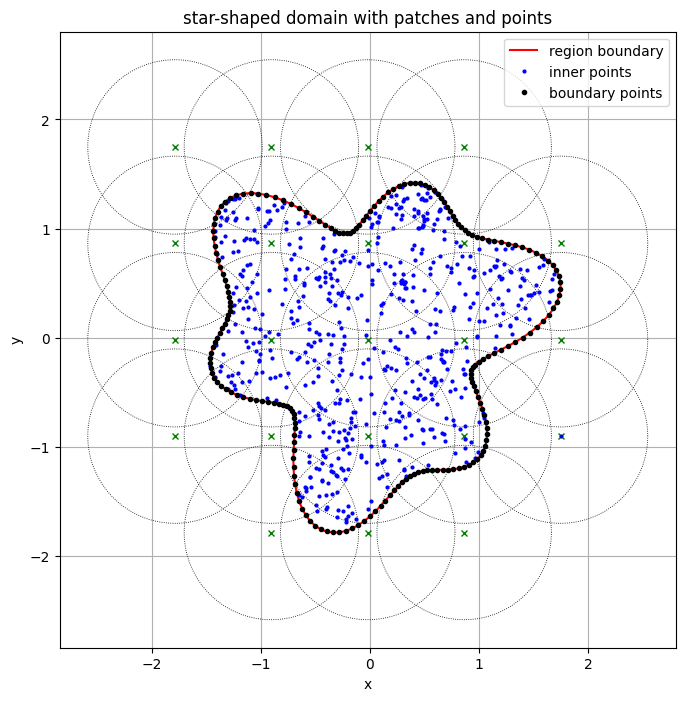

示例完成：
X_inner.shape = (615, 2)
X_boundary.shape = (200, 2)
patch centers shape = (22, 2)


In [ ]:
### 废弃代码


import numpy as np
from typing import Tuple, Dict, List
import matplotlib.pyplot as plt

def generator_points_star(N_patch_grid: int,
                          N_local_per_patch: int,
                          N_boundary: int,
                          R_ptch: float,
                          rng: np.random.Generator = None,
                          visualize: bool = True
                          ) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    在“星形区域”内生成 patch 覆盖、每个 patch 的局部 RBF center（内部点）以及边界点。
    参数与 MATLAB 版本兼容。

    Parameters
    ----------
    N_patch_grid : int
        patch 网格密度（每个维度上的 patch 数量）。
    N_local_per_patch : int
        每个 patch 希望保留的局部节点数（若候选点多则裁剪）。
    N_boundary : int
        用于边界的均匀采样点数量。
    R_ptch : float
        每个 patch 的半径（相同）。
    rng : np.random.Generator or None
        随机数生成器 (默认使用 numpy.default_rng())。
    visualize : bool
        是否绘制示意图（patch 圆圈、内部点、边界、区域边界）。

    Returns
    -------
    X_inner : np.ndarray, shape (N_in,2)
        合并后的内部点集合（所有 patch 的点并在 patch 内裁剪到 N_local_per_patch）。
    X_boundary : np.ndarray, shape (N_boundary,2)
        区域边界上的点。
    ptch : dict
        patch 信息字典，包含：
            'C' : (P,2) patch centers
            'R' : (P,) patch radii
            'keep_idx' : indices of kept patches from full grid
            'Xj_list' : list length P, each entry is ndarray of points for that patch
    """
    if rng is None:
        rng = np.random.default_rng()

    # ---------------------------
    # 1) 星形域极径函数 r_max(theta)
    # ---------------------------
    def r_max_func(theta: np.ndarray) -> np.ndarray:
        return 2.0 * (0.7 + 0.12 * (np.sin(6.0 * theta) + np.sin(3.0 * theta)))

    # 辅助: 判断点是否在星形区域内（包含边界容差）
    def is_inside_star(x: np.ndarray, y: np.ndarray, tol: float = 1e-12) -> np.ndarray:
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2.0 * np.pi, theta)
        r_limit = r_max_func(theta)
        return r <= (r_limit + tol)

    # ---------------------------
    # 2) 计算区域边界用于 patch 筛选与可视化
    # ---------------------------
    theta_plot = np.linspace(0.0, 2.0 * np.pi, 1000, endpoint=True)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    Domain_size = max(x_max - x_min, y_max - y_min)

    # ---------------------------
    # 3) Patch 网格及筛选
    # ---------------------------
    num_patches_1D = N_patch_grid
    # 保持和 MATLAB 逻辑一致的 del / patch_spacing 计算（但用不上 patch_spacing 后续计算）
    del_val = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1) if num_patches_1D > 1 else 0.0
    patch_spacing = 2.0 * R_ptch * (1.0 - del_val)

    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    xs = np.linspace(Grid_min, Grid_max, num_patches_1D)
    ys = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cx, Cy = np.meshgrid(xs, ys)
    C_all = np.vstack([Cx.ravel(), Cy.ravel()]).T  # (num_patches_1D^2, 2)
    R_all = R_ptch * np.ones((C_all.shape[0],))

    # 判断 patch 圆是否与星形边界有交集（通过圆上若干点是否在域内）
    theta_bdry = theta_plot  # reuse dense sampling for boundary check
    bc_x = C_all[:, 0:1] + (R_all[:, None] * np.cos(theta_bdry)[None, :])  # (num_centers, len(theta_bdry))
    bc_y = C_all[:, 1:1+1] + (R_all[:, None] * np.sin(theta_bdry)[None, :])
    # bc_x, bc_y are broadcasted shapes; check per-sample inside
    inside_flags = is_inside_star(bc_x, bc_y)    # boolean array same shape
    keep_mask = inside_flags.sum(axis=1) > 0     # keep patches with at least one intersection
    keep_idx = np.nonzero(keep_mask)[0]
    ptch_C = C_all[keep_idx, :]
    ptch_R = R_all[keep_idx]

    P = ptch_C.shape[0]
    print(f"保留的有效 Patch 数量 P = {P}, Patch 半径 R = {R_ptch}")

    # ---------------------------
    # 4) 在每个 patch 内生成局部点（极坐标面积均匀采样）
    # ---------------------------
    X_inner_list: List[np.ndarray] = []
    N_generate = int(np.floor(1.5 * N_local_per_patch))

    for i in range(P):
        Cx_i, Cy_i = ptch_C[i, 0], ptch_C[i, 1]
        R_i = ptch_R[i]

        # 极坐标均匀（面积）采样：theta ~ Uniform(0,2pi), r ~ sqrt(U)*R
        theta_local = rng.uniform(0.0, 2.0 * np.pi, size=(N_generate,))
        r_local = np.sqrt(rng.uniform(0.0, 1.0, size=(N_generate,))) * R_i

        x_local = r_local * np.cos(theta_local) + Cx_i
        y_local = r_local * np.sin(theta_local) + Cy_i

        inside = is_inside_star(x_local, y_local)
        Xcand = np.vstack([x_local[inside], y_local[inside]]).T

        if Xcand.shape[0] == 0:
            # 若该 patch 在域内没有候选点（罕见），则退化为 patch 的中心点
            Xcand = np.array([[Cx_i, Cy_i]])

        # 裁剪到目标数量
        if Xcand.shape[0] > N_local_per_patch:
            Xcand = Xcand[:N_local_per_patch, :]

        X_inner_list.append(Xcand)

    # 合并所有 patch 的点
    if len(X_inner_list) > 0:
        X_inner = np.vstack(X_inner_list)
    else:
        X_inner = np.zeros((0, 2))

    print(f"生成的内部点总数 = {X_inner.shape[0]} (目标每 patch {N_local_per_patch})")

    # ---------------------------
    # 5) 边界点（均匀）
    # ---------------------------
    theta_b = np.linspace(0.0, 2.0 * np.pi, N_boundary, endpoint=False)
    r_b = r_max_func(theta_b)
    x_b = r_b * np.cos(theta_b)
    y_b = r_b * np.sin(theta_b)
    X_boundary = np.vstack([x_b, y_b]).T
    print(f"边界点数量 = {X_boundary.shape[0]}")

    # ---------------------------
    # 6) 组织 ptch 字典（包含每个 patch 的本地点列表便于后续索引）
    # ---------------------------
    ptch = {
        'C': ptch_C,              # (P,2)
        'R': ptch_R,              # (P,)
        'keep_idx': keep_idx,     # indices in original grid
        'Xj_list': X_inner_list   # list of length P, each entry (n_j,2)
    }

    # ---------------------------
    # 7) 可视化（可选）
    # ---------------------------
    if visualize:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_aspect('equal')
        # plot patch circles
        theta_circ = np.linspace(0.0, 2.0 * np.pi, 200)
        for i in range(P):
            C = ptch_C[i]
            R = ptch_R[i]
            xc = C[0] + R * np.cos(theta_circ)
            yc = C[1] + R * np.sin(theta_circ)
            ax.plot(xc, yc, linestyle=':', color='k', linewidth=0.6)
            ax.plot(C[0], C[1], 'gx', markersize=4)

        # region boundary
        ax.plot(x_plot, y_plot, 'r-', linewidth=1.5, label='region boundary')

        # inner points
        if X_inner.shape[0] > 0:
            ax.plot(X_inner[:, 0], X_inner[:, 1], 'b.', markersize=4, label='inner points')

        # boundary points
        ax.plot(X_boundary[:, 0], X_boundary[:, 1], 'k.', markersize=6, label='boundary points')

        ax.set_title('star-shaped domain with patches and points')
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.legend()
        ax.grid(True)
        plt.show()

    return X_inner, X_boundary, ptch


# ---------------------------
# 最小示例（直接运行）
# ---------------------------
if __name__ == '__main__':
    # 示例参数（与 MATLAB 脚本默认值接近）
    N_patch_grid = 5
    N_local_per_patch = 55
    N_boundary = 200
    R_ptch = 0.8

    X_inner, X_boundary, ptch = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, rng=np.random.default_rng(10), visualize=True
    )

    print("示例完成：")
    print("X_inner.shape =", X_inner.shape)
    print("X_boundary.shape =", X_boundary.shape)
    print("patch centers shape =", ptch['C'].shape)


In [ ]:
# one_file_train_and_validate.py
# 完整脚本：生成点 -> 训练每个patch的eps -> 验证与可视化

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# 全局常量
_EPS = 1e-12
dtype = torch.float64


# ----------------------------
# 1. 星形区域点生成 (generator)
# ----------------------------
def generator_points_star(N_patch_grid=5, N_local_per_patch=80, N_boundary=200, R_ptch=0.8, rng_seed=None):
    if rng_seed is not None:
        np.random.seed(rng_seed)

    def r_max(theta):
        return 2 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))

    def isInsideStar(x, y):
        r = np.sqrt(x*x + y*y)
        theta = np.arctan2(y, x)
        theta[theta < 0] += 2*np.pi
        r_lim = r_max(theta)
        return (r <= r_lim + 1e-6)

    theta_plot = np.linspace(0, 2*np.pi, 1000)
    r_plot = r_max(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()

    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)
    Cx, Cy = np.meshgrid(Cx, Cy)
    C_all = np.vstack([Cx.flatten(), Cy.flatten()]).T
    R_all = np.ones(C_all.shape[0]) * R_ptch

    id_keep = []
    for i in range(C_all.shape[0]):
        cx, cy = C_all[i]
        dist = np.sqrt((x_plot - cx)**2 + (y_plot - cy)**2)
        if (dist <= R_ptch).any():
            id_keep.append(i)

    C = C_all[id_keep]
    R = R_all[id_keep]
    P = len(C)

    X_list = []
    N_generate = int(N_local_per_patch * 1.5)

    for j in range(P):
        cx, cy = C[j]
        theta_local = 2*np.pi*np.random.rand(N_generate)
        r_local = R[j]*np.sqrt(np.random.rand(N_generate))

        x_local = cx + r_local * np.cos(theta_local)
        y_local = cy + r_local * np.sin(theta_local)

        mask = isInsideStar(x_local, y_local)
        pts = np.vstack([x_local[mask], y_local[mask]]).T
        if pts.shape[0] == 0:
            pts = np.array([[cx, cy]])
        pts = pts[:N_local_per_patch]
        X_list.append(pts)

    X_inner = np.vstack(X_list)

    theta_b = np.linspace(0, 2*np.pi, N_boundary, endpoint=False)
    r_b = r_max(theta_b)
    xb = r_b * np.cos(theta_b)
    yb = r_b * np.sin(theta_b)
    X_boundary = np.vstack([xb, yb]).T

    ptch = {'C': C, 'R': R}
    return X_inner, X_boundary, ptch


def fill_distance(node: torch.Tensor) -> torch.Tensor:
    """
    计算节点分布的填充距离
    node: (N, d) 的张量
    返回: 标量 h
    """
    N = node.shape[0]

    # 计算所有点两两距离 (N,N)
    dist_matrix = torch.cdist(node, node, p=2)
    # 排除自己到自己的距离
    dist_matrix.fill_diagonal_(float('inf'))
    # 每个点到其他点的最小距离
    min_dists, _ = dist_matrix.min(dim=1)
    # 填充距离为所有最小距离的最大值
    h = min_dists.max()
    return h

# ----------------------------
# 2. Gaussian RBF 与导数
# ----------------------------
def phi_gauss(eps, x, xs):
    # x: (M,2)  xs: (n,2)  -> (M,n)
    r2 = torch.cdist(x, xs, p=2)**2
    return torch.exp(-(eps**2) * r2)

def laplace_phi_gauss(eps, x, xs):
    r2 = torch.cdist(x, xs, p=2)**2
    Phi = torch.exp(-(eps**2) * r2)
    return Phi * (4*(eps**4) * r2 - 4*(eps**2))

def dx1_phi_gauss(eps, x, xs):
    r2 = torch.cdist(x, xs, p=2)**2
    Phi = torch.exp(-(eps**2) * r2)
    diff = x[:,0].unsqueeze(1) - xs[:,0].unsqueeze(0)
    return Phi * (-2*(eps**2) * diff)

def dx2_phi_gauss(eps, x, xs):
    r2 = torch.cdist(x, xs, p=2)**2
    Phi = torch.exp(-(eps**2) * r2)
    diff = x[:,1].unsqueeze(1) - xs[:,1].unsqueeze(0)
    return Phi * (-2*(eps**2) * diff)


# ----------------------------
# 3. Wendland C2, Shepard 权重及导数
# ----------------------------
def wendland_C2(r: torch.Tensor):
    mask = (r <= 1.0).to(r.dtype)
    return mask * ((4*r + 1)*(1-r)**4)

def shepard_weights(Y: torch.Tensor, centers: torch.Tensor, radii: torch.Tensor):
    rdist = torch.cdist(Y, centers, p=2)
    rscaled = rdist / (radii.unsqueeze(0) + _EPS)
    Varphi = wendland_C2(rscaled)
    S = Varphi.sum(dim=1, keepdim=True)
    S = torch.where(S == 0, torch.tensor(_EPS, dtype=dtype, device=Y.device), S)
    return Varphi / S, Varphi, S

def diff_weights_torch(x: torch.Tensor, centers: torch.Tensor, radii: torch.Tensor):
    # 返回 dx_w, dy_w, d2_w (M,P)
    rdist = torch.cdist(x, centers, p=2)
    rscaled = rdist / (radii.unsqueeze(0) + _EPS)
    Varphi = wendland_C2(rscaled)
    S = Varphi.sum(dim=1, keepdim=True)
    S = torch.where(S == 0, torch.tensor(_EPS, dtype=dtype, device=x.device), S)
    mask = (rscaled <= 1.0).to(dtype)

    dx = x[:,0].unsqueeze(1) - centers[:,0].unsqueeze(0)
    dy = x[:,1].unsqueeze(1) - centers[:,1].unsqueeze(0)
    invR2 = 1.0/(radii**2 + _EPS)

    dx_varphi = -20*(1-rscaled)**3 * dx * invR2.unsqueeze(0) * mask
    dy_varphi = -20*(1-rscaled)**3 * dy * invR2.unsqueeze(0) * mask
    d2_varphi  = (1-rscaled)**2 * (20*(5*rscaled - 2) * invR2.unsqueeze(0)) * mask

    sum_dx = dx_varphi.sum(dim=1, keepdim=True)
    sum_dy = dy_varphi.sum(dim=1, keepdim=True)
    sum_d2 = d2_varphi.sum(dim=1, keepdim=True)

    dx_w = (S * dx_varphi - Varphi * sum_dx) / (S*S + _EPS)
    dy_w = (S * dy_varphi - Varphi * sum_dy) / (S*S + _EPS)
    d2_w = (S * d2_varphi - Varphi * sum_d2) / (S*S + _EPS) - 2*(dx_w * sum_dx + dy_w * sum_dy) / (S + _EPS)
    return dx_w, dy_w, d2_w


# ----------------------------
# 4. 从 ptch 构建 patches、以及全局 X, Yin, Yb（torch）
# ----------------------------
def build_patches(ptch, X_inner: np.ndarray, X_boundary: np.ndarray, tol=1e-8):
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner.copy()
    Yb = X_boundary.copy()
    C = ptch['C']
    R = ptch['R']
    P = len(C)

    dX = cdist(X, C) # (M,P)
    dYin = cdist(Yin, C) # (M1,P)
    dYb = cdist(Yb, C) # (M2,P)

    patches = []
    for j in range(P):
        idx_X = np.where(dX[:, j] <= R[j] + tol)[0].tolist()
        idx_Yi = np.where(dYin[:, j] <= R[j] + tol)[0].tolist()
        idx_Yb = np.where(dYb[:, j] <= R[j] + tol)[0].tolist()
        patches.append({
            'center': torch.tensor(C[j], dtype=dtype),
            'radius': float(R[j]),
            'idx_X': idx_X,
            'idx_Yi': idx_Yi,
            'idx_Yb': idx_Yb
        })

    return patches, torch.tensor(X, dtype=dtype), torch.tensor(Yin, dtype=dtype), torch.tensor(Yb, dtype=dtype)


# ----------------------------
# 5. 装配 L, RHS
# ----------------------------
def assemble_L_and_RHS(patches, eps_list, X, Yin, Yb, f_func, g_func, reg=1e-8):
    device = X.device
    P = len(patches)
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    N = X.shape[0]

    Y = torch.cat([Yin, Yb], dim=0)
    RHS = torch.cat([f_func(Yin), g_func(Yb)], dim=0)

    centers = torch.stack([p['center'] for p in patches], dim=0).to(device)
    radii = torch.tensor([p['radius'] for p in patches], dtype=dtype, device=device)

    W,_,_ = shepard_weights(Y, centers, radii)
    dx_w, dy_w, d2_w = diff_weights_torch(Yin, centers, radii)

    L = torch.zeros((M, N), dtype=dtype, device=device)

    for j, p in enumerate(patches):
        idx_X = p['idx_X']
        if len(idx_X) == 0:
            continue
        Xj = X[idx_X, :]
        eps_j = eps_list[j]

        Phi_YX = phi_gauss(eps_j, Yin, Xj)
        Dx_Phi = dx1_phi_gauss(eps_j, Yin, Xj)
        Dy_Phi = dx2_phi_gauss(eps_j, Yin, Xj)
        Lap_Phi = laplace_phi_gauss(eps_j, Yin, Xj)

        wj = W[:M1, j].reshape(-1, 1)
        dwjx = dx_w[:, j].reshape(-1, 1)
        dwjy = dy_w[:, j].reshape(-1, 1)
        dwj2 = d2_w[:, j].reshape(-1, 1)

        # Op_Y = (dwj2 * Phi_YX + 2*(Dx_Phi*dwjx + Dy_Phi*dwjy) + wj*Lap_Phi) @ U_star_j
        Lj = dwj2 * Phi_YX + 2 * (Dx_Phi * dwjx + Dy_Phi * dwjy) + wj * Lap_Phi
        Phi_jj = phi_gauss(eps_j, Xj, Xj)
        Rchol = torch.linalg.cholesky(Phi_jj+ reg*torch.eye(len(idx_X), dtype=dtype, device=device))
        U_star_j = torch.cholesky_solve(torch.eye(len(idx_X), dtype=dtype, device=device), Rchol)
        
        Cj = Lj @ U_star_j
        idx_X = torch.tensor(idx_X, dtype=torch.int32, device=device)
        L[:M1, idx_X] = L[:M1, idx_X] - Cj

        # boundary contributions

        Phi_bc = phi_gauss(eps_j, Yb, Xj)
        wv = W[M1:, j].reshape(-1, 1) # (M2,1) weight values
        Op_bc = (wv * Phi_bc) @ U_star_j
        L[M1:, idx_X] = L[M1:, idx_X] + Op_bc

    return L, RHS


# ----------------------------
# 6. 解 U_X 与预测 U_Y
# ----------------------------
def solve_UX_from_L(L, RHS, tol=1e-12):
    """
    L: M x N
    RHS: M
    Y, X: 用于判断是否 Y 与 X 相同
    """
    device = L.device
    # 点集一致，直接解线性方程
    if L.shape[0] == L.shape[1]:
        UX = torch.linalg.solve(L, RHS)
    else:
        # L: M x N, RHS: M, QR 分解
        
        Q, R = torch.linalg.qr(L, mode='reduced')  # Q: MxN, R: NxN
        print(L.shape, RHS.shape, Q.shape, R.shape)
        UX = torch.linalg.solve(R, Q.T @ RHS[:,None]).squeeze()

    return UX

def predict_UY(patches, eps_list, X, UX, Y, W_matrix=None, reg=1e-8):
    device = X.device
    P = len(patches)
    if W_matrix is None:
        centers = torch.stack([p['center'] for p in patches], dim=0).to(device)
        radii = torch.tensor([p['radius'] for p in patches], dtype=dtype, device=device)
        W_matrix, _, _ = shepard_weights(Y, centers, radii)

    UY = torch.zeros(Y.shape[0],1, dtype=dtype, device=device)
    for j, p in enumerate(patches):
        idx_X = p['idx_X']
        if len(idx_X) == 0:
            continue
        Xj = X[idx_X, :]
        eps_j = eps_list[j]
        Phi_jj = phi_gauss(eps_j, Xj, Xj)
        R = torch.linalg.cholesky(Phi_jj+ reg * torch.eye(len(idx_X), dtype=dtype, device=device))
        Cj = torch.cholesky_solve(torch.eye(len(idx_X),dtype=dtype, device=device), R) # (n_j, n_j) Phi_jj^{-1}
        Phi_YXj = phi_gauss(eps_j, Y, Xj)
        Lagr_Y = Phi_YXj @ Cj
        W = W_matrix[:, j:j+1]  # (M,1)
        UXj = UX[idx_X,None]  # (n_j,1)
        UY = UY +  W * (Lagr_Y @ UXj)
    return UY.squeeze() # (M,)


# ----------------------------
# 7. 训练 eps (将 log_eps 作为参数)
# ----------------------------
# def train_eps(patches, X, Yin, Yb, f_func, g_func, uY_true, epochs=20, device='cpu', lr=2e-3):
#     P = len(patches)
#     # 初始化 eps0（基于每个 patch 的局部 fill distance）
#     eps0_list = []
#     for j, p in enumerate(patches):
#         idx = p['idx_X']
#         if len(idx) < 2:
#             eps0_list.append(1.0)
#             continue
#         Xj = X[idx, :]
#         with torch.no_grad():
#             d2 = torch.cdist(Xj, Xj)
#             d2.fill_diagonal_(1e6)
#             minvals, _ = d2.min(dim=1)
#             h_j = float(minvals.max().cpu().item())
#         eps0_list.append(np.sqrt(1.0 / (10.0 * h_j + _EPS)))
#     eps0 = torch.tensor(eps0_list, dtype=dtype, device=device)

#     log_eps = nn.Parameter(torch.log(eps0.clone()).to(device))
#     optimizer = optim.Adam([log_eps], lr=lr)

#     Yall = torch.cat([Yin, Yb], dim=0)

#     for ep in range(epochs):
#         eps_list = torch.exp(log_eps)
#         L, RHS = assemble_L_and_RHS(patches, eps_list, X, Yin, Yb, f_func, g_func)
#         UX = solve_UX_from_L(L, RHS)
#         centers = torch.stack([p['center'] for p in patches], dim=0).to(device)
#         radii = torch.tensor([p['radius'] for p in patches], dtype=dtype, device=device)
#         W, _, _ = shepard_weights(Yall, centers, radii)
#         UY_pred = predict_UY(patches, eps_list, X, UX, Yall, W_matrix=W)

#         data_loss = ((UY_pred - uY_true)**2).mean()
#         eps_reg = 1e-4 * ((log_eps - torch.log(eps0.to(device)))**2).mean()
#         loss = data_loss + eps_reg

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         # 限制 log_eps 防止数值爆炸
#         with torch.no_grad():
#             log_eps.clamp_(min=torch.log(torch.tensor(1e-6, device=device)), max=torch.log(torch.tensor(1e1, device=device)))

#         if (ep % max(1, epochs//10) == 0) or (ep == epochs-1):
#             print(f"[train] epoch {ep+1}/{epochs} loss={loss.item():.3e} data={data_loss.item():.3e}")

#     learned_eps = torch.exp(log_eps).detach()
#     return learned_eps  # torch tensor on device

# ----------------------------
# 7. 训练 eps (直接优化 eps_j)
# ----------------------------
def train_eps(patches, X, Yin, Yb, f_func, g_func, uY_true, epochs=20, device='cpu', lr=2e-3):
    P = len(patches)
    # 初始化 eps0（基于每个 patch 的局部 fill distance）
    eps0_list = []
    for j, p in enumerate(patches):
        idx = p['idx_X']
        if len(idx) < 2:
            eps0_list.append(1.0)
            continue
        Xj = X[idx, :]
        with torch.no_grad():
            d2 = torch.cdist(Xj, Xj)
            d2.fill_diagonal_(1e6)
            minvals, _ = d2.min(dim=1)
            h_j = float(minvals.max().cpu().item())
        eps0_list.append(np.sqrt(1.0 / (100.0 * h_j + _EPS)))
    # eps0 = torch.tensor(eps0_list, dtype=dtype, device=device)
    # eps0 = fill_distance(X).repeat(P) ** (-0.5) * 0.5
    # eps0 = torch.ones((P,), dtype=dtype, device=device)

    # 直接优化 eps_j
    eps_j = nn.Parameter(eps0.clone().to(device))
    optimizer = optim.Adam([eps_j], lr=lr)

    # eps_min = 1e-5
    # eps_max = 1.0

    Yall = torch.cat([Yin, Yb], dim=0)

    best_loss = float('inf')
    best_eps = eps_j.detach().clone()

    for ep in range(epochs):
        L, RHS = assemble_L_and_RHS(patches, eps_j, X, Yin, Yb, f_func, g_func)
        UX = solve_UX_from_L(L, RHS)
        centers = torch.stack([p['center'] for p in patches], dim=0).to(device)
        radii = torch.tensor([p['radius'] for p in patches], dtype=dtype, device=device)
        W, _, _ = shepard_weights(Yall, centers, radii)
        UY_pred = predict_UY(patches, eps_j, X, UX, Yall, W_matrix=W)

        data_loss = ((UY_pred - uY_true)**2).mean()
        loss = data_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # # clamp eps_j 保证数值稳定
        # with torch.no_grad():
        #     eps_j.clamp_(eps_min, eps_max)

        # 保存最小误差的 eps_j
        if data_loss.item() < best_loss:
            best_loss = data_loss.item()
            best_eps = eps_j.detach().clone()

        if (ep % max(1, epochs//10) == 0) or (ep == epochs-1):
            print(f"[train] epoch {ep+1}/{epochs} loss={loss.item():.3e} data={data_loss.item():.3e}")

    return best_eps, eps0


# ----------------------------
# 8. 验证函数 validate_eps
#    @ UX
# ----------------------------
def validate_eps(patches, X, eps_list, Yin_test, Yb_test, Y_test, f_test, g_test, uY_true,
                 reg=1e-8, lambda_reg=1e-8, verbose=True):
    device = X.device
    dtype_local = X.dtype
    if not torch.is_tensor(eps_list):
        eps_t = torch.tensor(np.array(eps_list), dtype=dtype_local, device=device)
    else:
        eps_t = eps_list.to(device=device, dtype=dtype_local)

    L, RHS = assemble_L_and_RHS(patches, eps_t, X, Yin_test, Yb_test, f_test, g_test, reg=reg)
    UX = solve_UX_from_L(L, RHS, tol=lambda_reg)
    
    UY_pred = predict_UY(patches, eps_t, X, UX, Y_test, W_matrix=None, reg=reg)

    u_true = uY_true.detach().cpu().numpy()
    u_pred = UY_pred.detach().cpu().numpy()

    abs_err = np.abs(u_pred - u_true)
    L_inf = abs_err.max()
    RMSE = np.sqrt(np.mean((u_pred - u_true)**2))
    rel_L2 = np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-16)
    rel_Linf = L_inf / (np.max(np.abs(u_true)) + 1e-16)

    if verbose:
        print("Validation metrics:")
        print(f"  L_inf = {L_inf:.3e}")
        print(f"  RMSE  = {RMSE:.3e}")
        print(f"  rel_L2= {rel_L2:.3e}")
        print(f"  rel_Linf= {rel_Linf:.3e}")

    metrics = {
        'L_inf': float(L_inf),
        'RMSE': float(RMSE),
        'rel_L2': float(rel_L2),
        'rel_Linf': float(rel_Linf),
        'u_pred': UY_pred.cpu(),
        'UX': UX.cpu()
    }
    return metrics


# ----------------------------
# 9. main: 训练
# ----------------------------
if __name__ == "__main__":
    # 生成点
    X_in, X_bnd, ptch = generator_points_star(N_patch_grid=5, N_local_per_patch=50, N_boundary=100, R_ptch=0.8, rng_seed=10)

    # 构建 patches 与全局点 (torch)
    patches, X, Yin, Yb = build_patches(ptch, X_in, X_bnd) # Set Y_in = X_in, Yb = X_bnd to determine UX. when predicting UY, Y can be different.

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    X = X.to(device)
    Yin = Yin.to(device)
    Yb = Yb.to(device)
    for p in patches:
        p['center'] = p['center'].to(device)

    # PDE 定义（示例）
    def f_func(Y):
        x = Y[:,0]; y = Y[:,1]
        return 2.0 * torch.sin(x) * torch.cos(y)

    def g_func(Y):
        x = Y[:,0]; y = Y[:,1]
        return torch.sin(x) * torch.cos(y)

    # ground truth u 在训练 Y（这里用同样的 Yin / Yb）
    Yall = torch.cat([Yin, Yb], dim=0)
    uY_true = torch.sin(Yall[:,0]) * torch.cos(Yall[:,1])
    uY_true = uY_true.to(device)

    # 训练 eps
    epochs = 200
    learned_eps, eps0 = train_eps(patches, X, Yin, Yb, f_func, g_func, uY_true, epochs=epochs, device=device, lr=1e-3)
    learned_eps_cpu = learned_eps.cpu().numpy()
    print("\nlearned eps per patch:", learned_eps_cpu)
    print("\n eps0:", eps0)


[train] epoch 1/200 loss=4.553e-03 data=4.553e-03
[train] epoch 21/200 loss=9.163e+00 data=9.163e+00
[train] epoch 41/200 loss=6.284e-01 data=6.284e-01
[train] epoch 61/200 loss=2.134e-03 data=2.134e-03
[train] epoch 81/200 loss=5.443e-04 data=5.443e-04
[train] epoch 101/200 loss=3.317e-02 data=3.317e-02
[train] epoch 121/200 loss=5.593e-05 data=5.593e-05
[train] epoch 141/200 loss=3.267e-02 data=3.267e-02
[train] epoch 161/200 loss=4.246e-03 data=4.246e-03
[train] epoch 181/200 loss=3.472e-02 data=3.472e-02
[train] epoch 200/200 loss=3.712e-02 data=3.712e-02

learned eps per patch: [0.99250135 1.00492966 0.99503517 1.0029006  1.00553295 0.99445553
 0.99696515 0.99237068 1.00757029 0.99448542 0.99445273 1.00575694
 0.99422999 0.99706937 0.99450395 0.99507796 1.00754769 1.00487811
 0.99492452 1.00511055 1.00492411 1.00490489 1.00756359]

 eps0: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1.], device='cuda:0', dtype=torch.float6

Validation metrics:
  L_inf = 9.893e-05
  RMSE  = 1.523e-05
  rel_L2= 2.907e-05
  rel_Linf= 9.948e-05
Validation metrics:
  L_inf = 2.028e-05
  RMSE  = 3.886e-06
  rel_L2= 7.417e-06
  rel_Linf= 2.039e-05
torch.Size([1351, 733]) torch.Size([1351]) torch.Size([1351, 733]) torch.Size([733, 733])
Validation metrics:
  L_inf = 5.658e-06
  RMSE  = 9.231e-07
  rel_L2= 1.762e-06
  rel_Linf= 5.689e-06
torch.Size([1351, 733]) torch.Size([1351]) torch.Size([1351, 733]) torch.Size([733, 733])
Validation metrics:
  L_inf = 5.203e-06
  RMSE  = 8.960e-07
  rel_L2= 1.710e-06
  rel_Linf= 5.231e-06


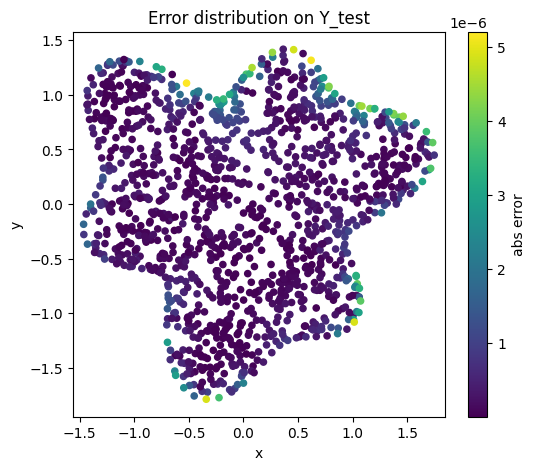

In [14]:
# ----------------------------
# 验证 10 - 使用不同的点集作为示例（可换成新的 Y_test / Yin, Yb）
# ----------------------------
Yin_test, Yb_test,_ = generator_points_star(N_patch_grid=5, N_local_per_patch=100, N_boundary=100, R_ptch=0.8, rng_seed=30)
Yin_test = torch.tensor(Yin_test, dtype=dtype, device=device)
Yb_test = torch.tensor(Yb_test, dtype=dtype, device=device)
Y_test = torch.cat([Yin_test, Yb_test], dim=0)
uY_true_test = torch.sin(Y_test[:,0]) * torch.cos(Y_test[:,1])
uY_true_test = uY_true_test.to(device)

metrics = validate_eps(patches, X, eps0, Yin, Yb, Y_test, f_func, g_func, uY_true_test, reg=1e-8, lambda_reg=1e-8)
metrics = validate_eps(patches, X, learned_eps, Yin, Yb, Y_test, f_func, g_func, uY_true_test, reg=1e-8, lambda_reg=1e-8)

metrics = validate_eps(patches, X, eps0, Yin_test, Yb_test, Y_test, f_func, g_func, uY_true_test, reg=1e-8, lambda_reg=1e-8)
metrics = validate_eps(patches, X, learned_eps, Yin_test, Yb_test, Y_test, f_func, g_func, uY_true_test, reg=1e-8, lambda_reg=1e-8)


# 可视化误差分布
Ycpu = Y_test.detach().cpu().numpy()
err = (metrics['u_pred'].detach().cpu().numpy() - uY_true_test.detach().cpu().numpy())
plt.figure(figsize=(6,5))
sc = plt.scatter(Ycpu[:,0], Ycpu[:,1], c=np.abs(err), s=20, cmap='viridis')
plt.colorbar(sc, label='abs error')
plt.title('Error distribution on Y_test')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal')
plt.show()

In [3]:
import numpy as np
import torch
from scipy.spatial.distance import cdist


# ============================================================
# ① 生成 canonical quasi-uniform 点集（单位圆）
# ============================================================
def generate_canonical_points_2d(N_ref=50, r=1.0, seed=123):
    np.random.seed(seed)
    # Fibonacci / Vogel disk
    idx = np.arange(1, N_ref+1)
    theta = idx * np.pi * (3 - np.sqrt(5))   # golden angle
    rho = np.sqrt(idx - 0.5) / np.sqrt(N_ref - 0.5)

    x = r * rho * np.cos(theta)
    y = r * rho * np.sin(theta)
    return np.vstack([x, y]).T   # (N_ref, 2)


# ============================================================
# ② RBF kernel + matrix construction
# ============================================================
def rbf_gaussian(X, Y, eps):
    # X:(N,2), Y:(M,2)
    d2 = cdist(X, Y)**2
    return np.exp(-(eps**2) * d2)


# ============================================================
# ③ 构造 RBF 重采样矩阵 P_j
#    P_j = Phi_ref,Xj * (Phi_Xj,Xj)^{-1}
# ============================================================
def build_rbf_resampling_matrix(X_j, X_ref, eps):
    """
    X_j   : (N_local, 2)   随机散点
    X_ref : (N_ref  , 2)   固定 canonical 点
    eps   : shape parameter
    return: (N_ref, N_local) 的重采样矩阵 P_j
    """

    N = X_j.shape[0]
    # 1. 构造 RBF 矩阵
    Phi_jj = rbf_gaussian(X_j, X_j, eps)           # (N,N)
    Phi_ref_j = rbf_gaussian(X_ref, X_j, eps)      # (N_ref,N)

    # 2. 稳定求逆（加 nugget）
    reg = 1e-10 * np.eye(N)
    Phi_inv = np.linalg.solve(Phi_jj + reg, np.eye(N))

    # 3. 得到重采样矩阵
    P_j = Phi_ref_j @ Phi_inv                      # (N_ref,N)
    return P_j


# ============================================================
# ④ 演示：把任意 patch 的 50 点 → canonical 点
# ============================================================
if __name__ == "__main__":
    # ====== canonical 50 点（固定） ======
    X_ref = generate_canonical_points_2d(N_ref=50, r=1.0)

    # ====== 任意 patch 50 散点（示例：在圆内随机） ======
    np.random.seed(1)
    theta = np.random.rand(50)*2*np.pi
    rho = np.sqrt(np.random.rand(50))
    X_j = np.column_stack([rho*np.cos(theta), rho*np.sin(theta)])

    # ====== 构造 P_j ======
    eps = 3.0
    P_j = build_rbf_resampling_matrix(X_j, X_ref, eps)

    print("P_j shape = ", P_j.shape)

    # ====== 测试：某个局部函数 u(x,y)=sin(pi x)cos(pi y) ======
    u_j = np.sin(np.pi*X_j[:,0]) * np.cos(np.pi*X_j[:,1])
    u_ref = P_j @ u_j

    print("u_ref shape=", u_ref.shape)


P_j shape =  (50, 50)
u_ref shape= (50,)
